# Results analysis notebook

This notebook was developed as part of the Master’s thesis of June Rossen and is one of two notebooks used to analyse the results of the wind power placement multi-objective optimization.

It is designed to process and visualise the results for a single scenario at a time. Provided one has all the necessary files, the notebook can be run as is.

## Workflow

The notebook follows the steps below:

1. List the available scenario names so that one can be selected for analysis.
2. Define the names of all relevant input files based on the chosen scenario and the corresponding run (when multiple runs exist).
3. Load all required data into variables.
4. Compile the multi-objective optimization (MOO) solutions into a single dataframe.
5. Extract and prepare the solutions of interest (MCDA and ROBUST).  
   See the *Results* section of the thesis for a detailed description of these solutions.
6. Generate the plots used for the analysis and discussion.
7. Optionally export selected outputs for further post-processing.
8. Provide additional plotting routines (not used in the thesis) in the final section for exploratory analysis.


In [66]:
#imports
import numpy as np
import geopandas as gpd
import pandas as pd
import dill

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from scipy.spatial.distance import pdist

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib import rcParams
import matplotlib.ticker as ticker

from matplotlib_venn import venn2
from matplotlib_venn import venn3

import seaborn as sns

from scipy.stats import pearsonr

from pymoo.visualization.scatter import Scatter
from pymoo.visualization.heatmap import Heatmap
from pymoo.visualization.petal import Petal
from pymoo.visualization.radar import Radar
from pymoo.visualization.radviz import Radviz
from pymoo.visualization.star_coordinate import StarCoordinate

plt.rcParams['font.family'] = 'serif'

# Preparing scenario and file names

In [ ]:
scenarios = ["100TWh", "NO1", "NO2", "NO3", "NO4", "NO5", "30TWh"]

s = 0

scenario = scenarios[s]
run = "Run1"

# This defines the minimum production requirement based on the chosen scenario
region_shares = [1, 0.257, 0.262, 0.210, 0.146, 0.124, 0.3]
min_production = 100_000 * region_shares[s]

# Total land surface of the respective scenarios, in km2
total_land_areas = [354037, 59889, 52426, 76948, 134522, 30252, 354037]
total_land_area = total_land_areas[s]

# Define all file names so there is no need to do it later
input_data_filename = "Input_optimization/" + scenario + "_normalized_merged.gpkg"
F_mcda_filename = "Input_optimization/" + scenario + "_F_mcda.npy"
X_mcda_filename =  "Input_optimization/" + scenario + "_X_mcda.csv"

results_filename = "Output_optimization/" + scenario + "_" + run + "_result.dill"

cb_X_filename = "Output_optimization/" + scenario + "_" + run + "_cb_X.npy"
cb_F_filename = "Output_optimization/" + scenario + "_" + run + "_cb_F.npy"
cb_gen_filename = "Output_optimization/" + scenario + "_" + run + "_cb_gen.npy"

hv_filename = "Output_optimization/" + scenario + "_" + run + "_hv_values.npy"

X_robustness_filename = "Output_optimization/" + scenario + "_" + run + "_X_robustness.gpkg"
X_robustness_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_X_robustness_centroid.gpkg"

most_robust_filename = "Output_optimization/" + scenario + "_" + run + "_most_robust.gpkg"
most_robust_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_most_robust_centroid.gpkg"


best_landscape_filename = "Output_optimization/" + scenario + "_" + run + "_best_landscape.gpkg"
best_sensitive_filename = "Output_optimization/" + scenario + "_" + run + "_best_sensitive.gpkg"
best_daily_filename = "Output_optimization/" + scenario + "_" + run + "_best_daily.gpkg"
best_culture_filename = "Output_optimization/" + scenario + "_" + run + "_best_culture.gpkg"
best_costs_filename = "Output_optimization/" + scenario + "_" + run + "_best_costs.gpkg"
best_technical_filename = "Output_optimization/" + scenario + "_" + run + "_best_technical.gpkg"
best_total_filename = "Output_optimization/" + scenario + "_" + run + "_best_total.gpkg"
best_objectives_7_filenames = [best_landscape_filename, best_sensitive_filename, best_daily_filename, best_culture_filename, best_costs_filename, best_technical_filename, best_total_filename]

best_landscape_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_landscape.gpkg"
best_sensitive_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_sensitive.gpkg"
best_daily_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_daily.gpkg"
best_culture_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_culture.gpkg"
best_costs_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_costs.gpkg"
best_technical_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_technical.gpkg"
best_total_centroid_filename = "Output_optimization/" + scenario + "_" + run + "_best_centroid_total.gpkg"
best_objectives_7_centroid_filenames = [best_landscape_centroid_filename, best_sensitive_centroid_filename, best_daily_centroid_filename, best_culture_centroid_filename, best_costs_centroid_filename, best_technical_centroid_filename, best_total_centroid_filename]

## Loading optimization results and important geodataframe data

In [68]:
# Download the geodataframe and the results file
my_input_data = gpd.read_file(input_data_filename)
with open(results_filename, 'rb') as f:
    res = dill.load(f)

# Add extra information to analyse available area, used area, number of turbines used, number of 3 MW and 5 MW turbines used
extra_info = gpd.read_file("data/SSB_techlegalfiltered_opticriteria.gpkg")

my_input_data_extra_info = my_input_data.merge(
    extra_info[["SSBid", "pct_NoGo", "potential_nb_3MW_turbines", "potential_nb_5MW_turbines", "Best_turbine_model", "nb_turbines"]],
    left_on="SSBid",
    right_on="SSBid",
    how="left")

my_input_data_extra_info["Available surface"] = 1 - my_input_data_extra_info["pct_NoGo"]
my_input_data_extra_info["Number turbines"] = my_input_data_extra_info["nb_turbines"]

my_input_data_extra_info["Number 3MW turbines"] = np.where(
    my_input_data_extra_info["Best_turbine_model"] == "avg_AEP_3MW",
    my_input_data_extra_info["potential_nb_3MW_turbines"], 0
)

my_input_data_extra_info["Number 5MW turbines"] = np.where(
    my_input_data_extra_info["Best_turbine_model"] == "avg_AEP_5MW",
    my_input_data_extra_info["potential_nb_5MW_turbines"], 0
)

my_input_data_extra_info.drop(columns=["nb_turbines", "potential_nb_3MW_turbines", "potential_nb_5MW_turbines"], inplace=True)

In [69]:
print("Total possible energy production [TWh]:", my_input_data_extra_info["AEP_GWh"].sum()/1000)
print("Total available area [km2]:", my_input_data_extra_info["Available surface"].sum())
display(my_input_data_extra_info)

Total possible energy production [TWh]: 5595.86252912475
Total available area [km2]: 106613.420625


,SSBid,Komm2016,Fylk2016,AEP_GWh,Daily_exposure,Culture,Landscape_change,Sensitive_fauna,Technical_difficulty,Costs,geometry,pct_NoGo,Best_turbine_model,Available surface,Number turbines,Number 3MW turbines,Number 5MW turbines
0,22990006544000,0101,01,56.138838,0.765334,0.5,0.685248,0.294641,0.405928,0.323949,"MULTIPOLYGON (((4408499.644 3988462.997, 44075...",1.125000e-02,avg_AEP_5MW,0.988750,3.0,0.0,3.0
1,22990006545000,0101,01,58.830618,0.766777,0.5,0.700830,0.290500,0.409170,0.321255,"MULTIPOLYGON (((4408425.191 3989458.236, 44074...",0.000000e+00,avg_AEP_5MW,1.000000,3.0,0.0,3.0
2,22990006550000,0101,01,44.460408,0.782473,0.0,0.686928,0.246901,0.405189,0.280815,"MULTIPOLYGON (((4408052.815 3994434.348, 44070...",1.937500e-02,avg_AEP_3MW,0.980625,4.0,4.0,0.0
3,22980006555000,0101,01,57.481866,0.837400,0.5,0.686424,0.226802,0.409030,0.279645,"MULTIPOLYGON (((4406681.094 3999336.954, 44056...",1.110223e-16,avg_AEP_5MW,1.000000,3.0,0.0,3.0
4,22990006555000,0101,01,61.573668,0.744955,0.5,0.714630,0.224913,0.418110,0.265917,"MULTIPOLYGON (((4407680.258 3999410.323, 44066...",1.110223e-16,avg_AEP_5MW,1.000000,3.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134278,31040007818000,2030,20,34.268688,0.108004,0.5,0.529125,0.181380,0.422055,0.107681,"MULTIPOLYGON (((5120420.194 5303057.846, 51194...",5.168750e-01,avg_AEP_3MW,0.483125,2.0,2.0,0.0
134279,31050007818000,2030,20,36.018080,0.102361,1.0,0.466677,0.138479,0.417561,0.127799,"MULTIPOLYGON (((5121425.654 5303108.24, 512042...",4.856250e-01,avg_AEP_3MW,0.514375,2.0,2.0,0.0
134280,31020007819000,2030,20,55.297680,0.116205,0.5,0.533279,0.362546,0.422089,0.118537,"MULTIPOLYGON (((5118336.321 5303939.79, 511733...",3.825000e-01,avg_AEP_5MW,0.617500,2.0,0.0,2.0
134281,31030007819000,2030,20,61.319484,0.110484,1.0,0.478569,0.197009,0.420573,0.115811,"MULTIPOLYGON (((5119341.831 5303990.254, 51183...",1.900000e-01,avg_AEP_5MW,0.810000,2.0,0.0,2.0


# Prepare the MOO solutions

In [70]:
# # To use if result file is not available (ex: to big for upload in Google colab)
# cb_X = np.load(cb_X_filename)
# cb_F = np.load(cb_F_filename)
# cb_gen = np.load(cb_gen_filename)

callback_X = res.algorithm.callback.X
cb_X = np.stack(callback_X, axis=0)
callback_F = res.algorithm.callback.F
cb_F = np.stack(callback_F, axis=0)
cb_gen = res.algorithm.callback.gen

hv_values = np.load(hv_filename)

In [71]:
# All lists of names
objective_names = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty"
]
objective_names_plot_labels = [
    "Landscape\nchange", "Sensitive\nfauna",
    "Daily\nexposure", "Culture",
    "Costs", "Technical\ndifficulty"
]

objective_names_per_TWh = [
    "Landscape change per TWh", "Sensitive fauna per TWh",
    "Daily exposure per TWh", "Culture per TWh",
    "Costs per TWh", "Technical difficulty per TWh"
]

objective_names_7 = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty",
    "Total impact"
]

objective_names_8 = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty",
    "Total impact", "Most robust"
]

solutions_of_focus = ["LAND", "FAUNA", "DAILY", "CULTURE", "COST", "TECH", "TOTAL", "ROBUST"]

metrics_of_interest_plot_labels = ["Total\nimpact", "Total area\n[$\\mathregular{km^2}$]", "Number\nturbines", "Number 3MW\nturbines", "Number 5MW\nturbines"]
metrics_of_interest_absolute = ["Total impact", "Total area km2", "Number turbines", "Number 3MW turbines", "Number 5MW turbines"]
metrics_of_interest_per_TWh = ["Total impact per TWh", "Total area km2 per TWh", "Number turbines per TWh", "Number 3MW turbines per TWh", "Number 5MW turbines per TWh"]

metrics_absolute = objective_names + metrics_of_interest_absolute
metrics_per_TWh = objective_names_per_TWh + metrics_of_interest_per_TWh

overarching_objective_names = ["Environmental objectives", "Social objectives", "Techno-economic objectives"]

In [ ]:
### Create the dataframe of solutions, based on the objective values of the solutions

X = res.X
F = res.F
G = res.G

number_solutions = X.shape[0]

solution_df = pd.DataFrame(F, columns=objective_names)

# Add metrics of interest, such as energy production, number of cells kept, total impact, total area necessary, as well as number of turbines necessary (total, 3 MW and 5 MW)
production = X @ my_input_data['AEP_GWh'].values
solution_df["Production"] = production
# F_per_TWh = solution_df[objective_names] / solution_df["Production"]

kept_cells = X.sum(axis=1)
solution_df["Cells_kept"] = kept_cells

solution_df["Total impact"] = F.sum(axis=1)

solution_df["Total area km2"] = X @ my_input_data_extra_info["Available surface"].values

solution_df["Number turbines"] = X @ my_input_data_extra_info["Number turbines"].values
solution_df["Number 3MW turbines"] = X @ my_input_data_extra_info["Number 3MW turbines"].values
solution_df["Number 5MW turbines"] = X @ my_input_data_extra_info["Number 5MW turbines"].values

# Normalize all of those metrics, as well as the objective values, by the corresponding energy production
solution_df[metrics_per_TWh] = 1000 * solution_df[metrics_absolute].div(solution_df["Production"], axis=0)

solution_df["Total land area km2"] = total_land_area
solution_df["Fraction area usage"] = solution_df["Total area km2"] / solution_df["Total land area km2"]

display(solution_df)

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,Number turbines,Number 3MW turbines,Number 5MW turbines,Landscape change per TWh,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh,Total land area km2,Fraction area usage
0,1095.266992,226.475670,901.264676,25.5,390.788243,745.266096,100002.662957,1677,3384.561677,1585.502500,5103.0,1453.0,3650.0,10.952378,2.264696,9.012407,0.254993,3.907778,7.452463,33.844715,15.854603,51.028641,14.529613,36.499028,354037,0.004478
1,615.462457,116.556757,297.299435,922.0,65.531327,648.589815,100073.614436,1214,2665.439791,1185.028750,3751.0,790.0,2961.0,6.150097,1.164710,2.970807,9.213218,0.654831,6.481127,26.634791,11.841570,37.482408,7.894189,29.588219,354037,0.003347
2,849.115982,30.443234,515.946884,1341.0,278.430758,934.508097,100012.241069,1706,3949.444955,1391.965625,4463.0,1607.0,2856.0,8.490121,0.304395,5.158837,13.408359,2.783967,9.343937,39.489616,13.917953,44.624537,16.068033,28.556504,354037,0.003932
3,1096.787137,228.629131,900.367958,28.0,389.595916,746.434439,100024.829718,1680,3389.814580,1586.273125,5102.0,1450.0,3652.0,10.965149,2.285724,9.001445,0.279930,3.894992,7.462491,33.889731,15.858794,51.007335,14.496401,36.510934,354037,0.004481
4,694.767183,200.432443,479.173195,923.5,164.012595,521.154019,100005.032473,1297,2983.039434,1252.000000,3803.0,368.0,3435.0,6.947322,2.004224,4.791491,9.234535,1.640043,5.211278,29.828893,12.519370,38.028086,3.679815,34.348271,354037,0.003536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,1053.742729,216.215083,843.434106,61.5,345.607772,722.337892,100692.388537,1623,3242.837583,1547.761875,4977.0,1378.0,3599.0,10.464969,2.147283,8.376344,0.610771,3.432313,7.173709,32.205389,15.371190,49.427768,13.685245,35.742523,354037,0.004372
396,922.164726,153.862285,717.613702,192.0,290.987613,718.614122,100934.835369,1532,2995.242449,1457.568125,4671.0,1212.0,3459.0,9.136238,1.524372,7.109673,1.902217,2.882926,7.119585,29.675012,14.440685,46.277383,12.007747,34.269635,354037,0.004117
397,914.112382,202.932302,624.916578,282.0,267.610736,687.554359,100015.506857,1475,2979.126357,1397.771875,4458.0,1117.0,3341.0,9.139707,2.029008,6.248197,2.819563,2.675692,6.874478,29.786645,13.975552,44.573088,11.168268,33.404820,354037,0.003948
398,700.009947,115.158000,143.777318,710.0,228.366491,745.589267,100021.457157,1342,2642.901023,1320.863750,4099.0,547.0,3552.0,6.998598,1.151333,1.437465,7.098477,2.283175,7.454293,26.423341,13.205804,40.981207,5.468827,35.512380,354037,0.003731


In [73]:
### Double-check that all solutions are Pareto optimal among themselves
nds = NonDominatedSorting()
fronts = nds.do(F)
pareto_final_pop = fronts[0]
print(f"Non-dominated final individuals: {len(pareto_final_pop)}")


Non-dominated final individuals: 400


# Prepare the MCDA and ROBUST solutions
- 6 MCDA solutions
- 1 MCDA total impact solution
- 1 ROBUST cells solution

In [74]:
# Get the MCDA results
F_mcda = np.load(F_mcda_filename)
X_mcda = np.loadtxt(X_mcda_filename, dtype=int, delimiter=",")
Fmin, Fmax = F_mcda.min(axis=0), F_mcda.max(axis=0)

# Keep the following objective order: landscape change, birds, daily exposure, culture, costs, technical difficulty, and total impact
mcda_color_scale_7_objectives = ['#2ca02c', '#1f77b4','#e377c2','#9467bd','#ff7f0e','#d62728','#8c564b']
mcda_color_scale_8_objectives = ['#2ca02c', '#1f77b4','#e377c2','#9467bd','#ff7f0e','#d62728','#8c564b', '#fdd13f']

# When the MCDA solutions were initially generated, the order of the indicators was different than currently, and there were additional indicators. This cell fixes this for the results analysis notebook.
# initial order = ["AEP_GWh_efficient", "Daily_exposure", "Culture", "Landscape_change", "Sensitive_fauna", "Technical_difficulty", "Costs", "Social_indicator", "Environmental_indicator", "Technical_indicator", "Global_indicator"]
rows_6 = [3, 4, 1, 2, 6, 5]         # just the 6 main optimization objectives
rows_7 = [3, 4, 1, 2, 6, 5, 10]     # including the total impacts

F_mcda_6_objectives = F_mcda[rows_6]
F_mcda_7_objectives = F_mcda[rows_7]

X_mcda_6_objectives = X_mcda[rows_6]
X_mcda_7_objectives = X_mcda[rows_7]

In [75]:
### Calculates the frequency at which cells were selected by the final MOO Pareto optimal solutions,
# plots the resulting map and returns the geodataframe with this additional information.
def plot_X_robustness(X=X, my_input_data=my_input_data): 
    unit_counts = {}
    for i in range(len(my_input_data)):
        unit_counts[i] = 0

    # Iterate through the optimal solutions
    for solution in X:
        # Get indices of selected units (assuming binary solutions)
        selected_indices = np.where(solution == True)[0]
        # Increment counts for selected units
        for idx in selected_indices:
            unit_counts[idx] += 1

    # Print the counts
    #for unit_id, count in unit_counts.items():
    #    print(f"Planning Unit {unit_id}: {count} occurrences")
    count_series = pd.Series({k: v for k, v in unit_counts.items()}, name="Optimizer_selection_count")
    my_input_data_temp = my_input_data.copy().reset_index(drop=True)  # Drop the old index
    if "Optimizer_selection_count" in my_input_data_temp.columns:
        my_input_data_temp = my_input_data_temp.drop(columns="Optimizer_selection_count")
    my_input_data_temp = my_input_data_temp.join(count_series)
    my_input_data_temp["Optimizer_selection_frequency"] = my_input_data_temp["Optimizer_selection_count"] / len(X)
    # Threshold for continuous color scale
    threshold = 0
    #threshold = 0.01  # adjust as needed

    # Additional information needed for future maps
    my_input_data_temp["Total impact per TWh"] = 1000 * (my_input_data["Daily_exposure"] + my_input_data["Culture"] + my_input_data["Landscape_change"] + my_input_data["Sensitive_fauna"] + my_input_data["Technical_difficulty"] + my_input_data["Costs"]) / my_input_data["AEP_GWh"]
    max_tot_impact_per_TWh, min_tot_impact_per_TWh = my_input_data_temp["Total impact per TWh"].max(), my_input_data_temp["Total impact per TWh"].min()
    my_input_data_temp["Total impact per TWh normalized"] = (1 - (my_input_data_temp["Total impact per TWh"] - min_tot_impact_per_TWh) / (200 - min_tot_impact_per_TWh)).clip(0, 1)     # took a maximum value of 200 because higher values simply indicate so little AEP and/or so much total impact in a cell that it is not worth considering


    # Copy to avoid SettingWithCopyWarning
    gdf = my_input_data_temp.copy()

    # Values below threshold should not influence the continuous colormap
    gdf["color_value"] = gdf["Optimizer_selection_frequency"].where(
        gdf["Optimizer_selection_frequency"] > threshold,
        None  # or np.nan
    )

    # Discrete bins (edit as needed)
    bins = [threshold, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    labels = ["0.0–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.5", "0.5–0.6", "0.6–0.7", "0.7–0.8", "0.8–0.9", "0.9–1.0"]

    # Right boundary is included in the cut
    gdf["bin"] = pd.cut(
        gdf["Optimizer_selection_frequency"],
        bins=bins,
        labels=labels,
        include_lowest=False
    )

    # Discrete colormap
    cmap = plt.get_cmap("viridis", len(labels))

    fig, ax = plt.subplots(figsize=(12, 12))

    gdf.plot(
        column="bin",
        ax=ax,
        cmap=cmap,
        linewidth=0.2,
        edgecolor=None,
        missing_kwds={
            "color": "white", 
            "edgecolor": "lightgrey", 
            "label": f"< {threshold}"}
    )

    # Discrete colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=mcolors.BoundaryNorm(range(len(labels)+1), cmap.N)
    )
    cbar = fig.colorbar(sm, ax=ax, ticks=np.arange(len(labels)) + 0.5)
    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Chosen cell frequency")

    ax.set_title("Cell robustness")
    plt.show()

    return gdf


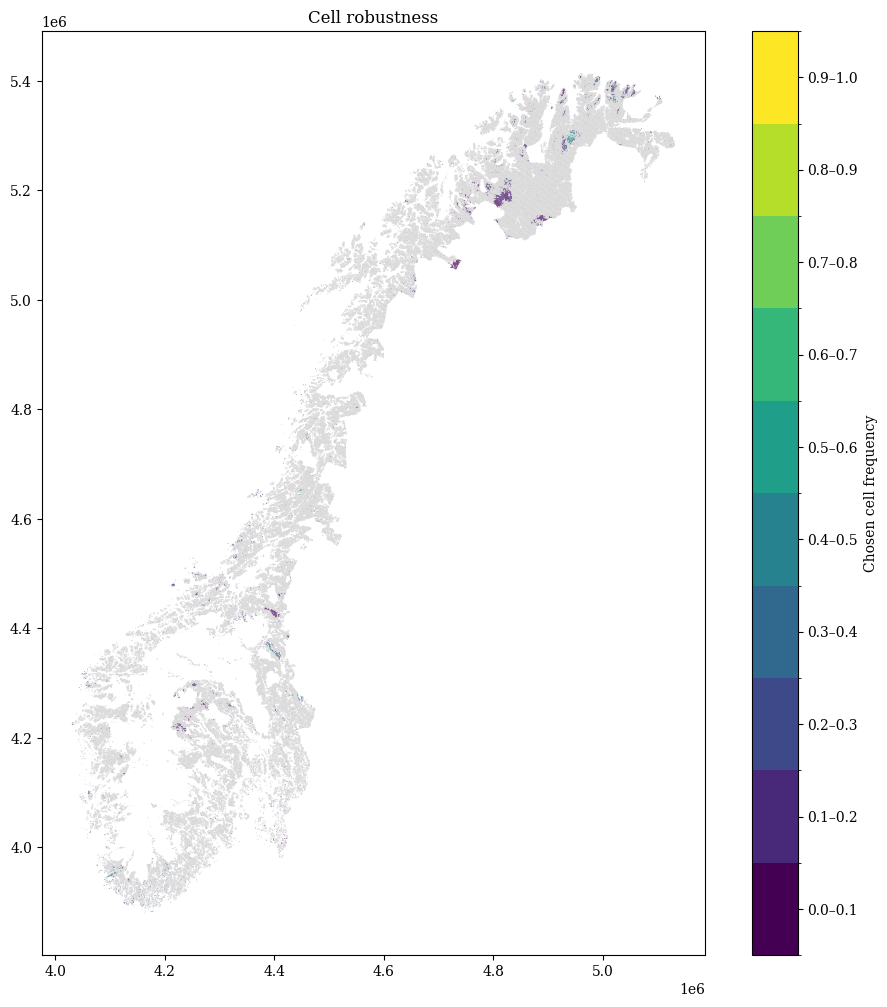

In [76]:
X_robustness = plot_X_robustness(X, my_input_data)

In [77]:
### Prepare the ROBUST solution of focus and add it after the 7 other solutions of focus

X_robustness_sorted = X_robustness.sort_values("Optimizer_selection_count", ascending=False).copy()
X_robustness_sorted["Cumulative_prod"] = X_robustness_sorted["AEP_GWh"].cumsum()

# a convoluted way of selecting the first cell which has a cumulative production greater or equal to (ge()) the minimum production desired, in a dataframe sorted by decreasing robustness of cells
most_robust = X_robustness_sorted.loc[:X_robustness_sorted["Cumulative_prod"].ge(min_production).idxmax()].copy()

F_most_robust = most_robust[["Landscape_change", "Sensitive_fauna", "Daily_exposure", "Culture", "Costs", "Technical_difficulty"]].sum().to_numpy()
print("F vector of ROBUST:", F_most_robust)
print("Total impact for ROBUST: ", F_most_robust.sum())

# ensure the geodataframe used is the same that was used for generating the MCDA solutions, the order of cells is important
X_most_robust = my_input_data_extra_info["SSBid"].isin(most_robust["SSBid"].values).to_numpy().astype(int)      

F_mcda_8_objectives = np.vstack([F_mcda_7_objectives, F_most_robust])
X_mcda_8_objectives = np.vstack([X_mcda_7_objectives, X_most_robust])

F vector of ROBUST: [757.86326017 125.93242645 505.79950124 333.5        176.34913351
 652.26379148]
Total impact for ROBUST:  2551.7081128441996


In [78]:
# Calculate MCDA+ROBUST productions and per TWh objective values
production_mcda_8_objectives = X_mcda_8_objectives @ my_input_data['AEP_GWh'].values
F_mcda_per_TWh_6_objectives = 1000 * F_mcda_6_objectives / production_mcda_8_objectives[:-2,None]
F_mcda_per_TWh_7_objectives = 1000 * F_mcda_7_objectives / production_mcda_8_objectives[:-1,None]
F_mcda_per_TWh_8_objectives = 1000 * F_mcda_8_objectives / production_mcda_8_objectives[:,None]

## Run a couple of diagnostic checks on the results of the MOO

In [79]:
### Checks the dominances between MCDA and MOO solutions
def dominates(a, b):
    """
    Returns True if solution a dominates solution b (minimization).
    """
    return np.all(a <= b) and np.any(a < b)

def mcda_dominates_nsga(F_1, F_2):
    """
    Checks if ANY F_1 solution dominates ANY F_2 solution.
    """
    dominating_pairs = []

    for i, mc in enumerate(F_1):
        for j, ns in enumerate(F_2):
            if dominates(mc, ns):
                dominating_pairs.append((i, j))

    return dominating_pairs


pairs = mcda_dominates_nsga(F_mcda, F)
print(f"MCDA → NSGA dominating pairs: {len(pairs)}")
if pairs:
    print("Example dominating pair (mcda_idx, nsga_idx):", pairs[0])
print()

pairs_nsga = mcda_dominates_nsga(F, F_mcda)
print(f"NSGA → MCDA dominating pairs: {len(pairs_nsga)}")
if pairs_nsga:
    print("Example dominating pair (nsga_idx, mcda_idx):", pairs_nsga[0])
print()


MCDA → NSGA dominating pairs: 13
Example dominating pair (mcda_idx, nsga_idx): (0, 25)

NSGA → MCDA dominating pairs: 0



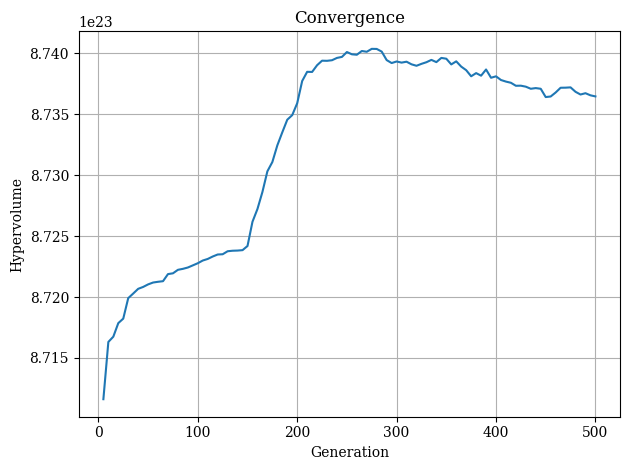

In [80]:
### Plots the hypervolume as a basic diagnostic of the MOO
def plot_hypervolume(hv_values=hv_values, generations=cb_gen):
    plt.plot(generations, hv_values)
    plt.xlabel("Generation")
    plt.ylabel("Hypervolume")
    plt.title("Convergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_hypervolume()

# Pareto analysis

In [81]:
### Print summary statistics of the solutions
pd.set_option('display.max_columns', None)
display(solution_df.describe())

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,Number turbines,Number 3MW turbines,Number 5MW turbines,Landscape change per TWh,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh,Total land area km2,Fraction area usage
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.0,400.000000
mean,799.626336,138.500215,470.039995,622.042500,232.009358,711.680711,100508.250210,1424.367500,2973.899115,1347.066859,4227.837500,826.702500,3401.135000,7.956947,1.378454,4.680108,6.188567,2.308568,7.080222,29.592866,13.402962,42.065991,8.227171,33.838819,354037.0,0.003805
std,151.721554,56.500396,234.461591,381.544243,85.613653,95.608073,1129.804084,163.691278,387.471788,127.207069,480.911047,462.298891,213.977857,1.514768,0.563931,2.338392,3.797411,0.852801,0.944233,3.876417,1.263136,4.781727,4.608356,2.086400,0.0,0.000359
min,546.095898,30.443234,60.235821,0.000000,65.531327,521.154019,100000.017342,1140.000000,2147.343969,1132.083750,3410.000000,18.000000,2856.000000,5.460698,0.304395,0.602040,0.000000,0.654831,5.211278,21.472644,11.320297,34.098373,0.179988,28.508099,354037.0,0.003198
25%,678.403281,101.037819,290.526368,268.875000,160.071419,642.565863,100015.855071,1280.000000,2708.252679,1239.454375,3798.750000,389.250000,3306.750000,6.761812,0.998808,2.895465,2.682004,1.578989,6.406173,27.013461,12.337597,37.816875,3.860316,32.878913,354037.0,0.003501
50%,782.973016,146.544669,465.378132,688.750000,236.088717,709.105783,100038.427340,1429.500000,2974.518334,1355.109375,4271.500000,831.000000,3423.000000,7.781986,1.455298,4.628041,6.873877,2.358469,7.050741,29.649194,13.358599,42.237229,8.308618,34.186493,354037.0,0.003828
75%,914.246713,184.999920,626.876097,911.500000,297.925049,762.399164,100465.159775,1561.000000,3217.231035,1437.471094,4570.000000,1264.000000,3562.000000,9.114503,1.836724,6.238998,9.053434,2.976066,7.562892,32.000969,14.297462,45.332945,12.589568,35.483781,354037.0,0.004060
max,1096.787137,233.925125,917.806984,1366.000000,390.788243,935.358486,109971.713912,1710.000000,3953.670980,1586.646875,5108.000000,1652.000000,3874.000000,10.965149,2.339045,9.165616,13.659658,3.907778,9.343937,39.489616,15.858794,51.030455,16.267834,37.243270,354037.0,0.004482


In [82]:
### Parallel coordinates plot of the objective values
def parallel_coordinates(F, F_mcda=None,
                         score=None, cbar_label=None, x_labels=None, y_label=None, axis_limits_step=None, cm_lim=(18, 52), cmap="turbo",
                         colors_mcda=mcda_color_scale_8_objectives, legend_labels=objective_names_8, rotation_xlabel=0,
                         lw=0.6, alpha=0.6, lw_mcda=0.8, alpha_mcda=1, figsize=(11, 5)):
    n_sol, n_obj = F.shape
    x = np.arange(n_obj)
    vmin, vmax, step = axis_limits_step
    F_plot = F.copy().astype(float)

    fig, ax = plt.subplots(figsize=figsize)

    # ----- color mapping -----
    if score is None:
        colors = ["lightgrey"] * n_sol
        sm = None
    else:
        score_min, score_max = cm_lim
        norm = Normalize(score_min, score_max)
        cmap = plt.get_cmap(cmap)
        colors = cmap(norm(score))
        sm = ScalarMappable(norm=norm, cmap=cmap)

    # ----- draw lines -----
    for i in range(n_sol):
        ax.plot(x, F_plot[i], color=colors[i], lw=lw, alpha=alpha)

    if F_mcda is not None:
        for i in range(len(colors_mcda)):
            if i > len(colors_mcda) - 3:
                ax.plot(x, F_mcda[i], ls="--", color=colors_mcda[i], linewidth=lw_mcda, alpha=alpha_mcda, label=legend_labels[i])
            else:
                ax.plot(x, F_mcda[i], color=colors_mcda[i], linewidth=lw_mcda, alpha=alpha_mcda, label=legend_labels[i])

    # ----- vertical axes -----
    for j in np.arange(n_obj):
        ax.vlines(j, vmin, vmax, color="grey", lw=1)

    # ----- ticks and labels -----
    ax.set_xlim(0, n_obj-0.99)
    ax.set_xticks(x)
    ax.set_yticks(np.arange(vmin, vmax+1, step))
    
    if y_label is not None:
        ax.set_ylabel(y_label)
    
    if x_labels is not None:
        ax.set_xticklabels(x_labels, fontweight='bold', rotation=rotation_xlabel)

    ax.spines[:].set_visible(False)

    # ----- colorbar -----
    if cbar_label is not None:
        cbar = fig.colorbar(sm, ax=ax, pad=0.05)
        cbar.set_label(cbar_label, fontweight='bold')


    # ----- legend -----
    if F_mcda is not None:
        ax.legend(
            title="Solution",
            loc="upper right",
            #bbox_to_anchor=(1, 1.04),
            title_fontproperties={'weight': 'bold'},
        )
    
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


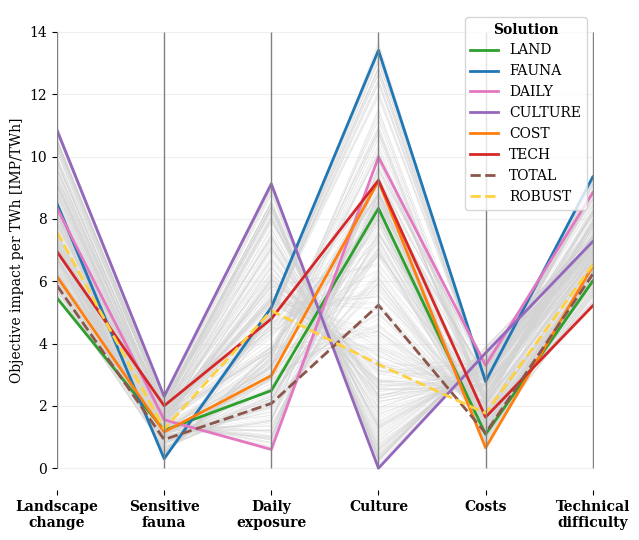

In [83]:
parallel_coordinates(
    solution_df[objective_names_per_TWh].values,
    F_mcda=F_mcda_per_TWh_8_objectives,
    score=None,      #solution_df["Total impact per TWh"].values,       # uncomment if want to see colors by total impact per TWh value
    cbar_label=None,    #"Total impact per TWh",       # uncomment if want to see colors by total impact per TWh value
    x_labels=objective_names_plot_labels, #["LAND", "FAUNA", "DAILY", "CULTURE", "COST", "TECH"],      #objective_names,
    y_label="Objective impact per TWh [IMP/TWh]",
    legend_labels=solutions_of_focus,
    rotation_xlabel=0,
    axis_limits_step=(0, 14, 2),
    lw=0.3,
    alpha=0.6,
    lw_mcda=2,
    alpha_mcda=1,
    figsize=(6.5,5.5)
)

# for large plots to put alone on a line on A4 paper: figsize=(8,5.5)

# for small plots to put side by side on A4: figsize=(6.5,5.5)

Approximate range of total impact per TWh, per scenario:

0: 20-40

1: 26-44

2: 30-42

3: 28-43

4: 18-46

5: 38-51

6: 20-40

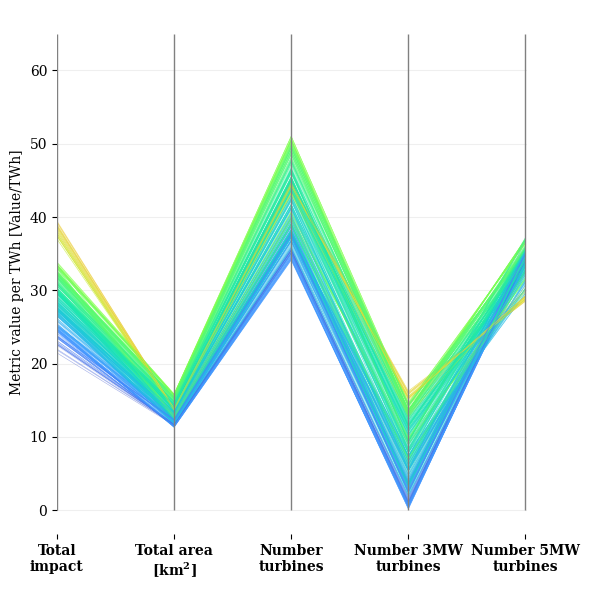

In [84]:
### One can use the same plot to analyse the MOO solutions over other evaluation metrics
parallel_coordinates(
    solution_df[metrics_of_interest_per_TWh].values,
    F_mcda=None,
    score=solution_df["Total impact per TWh"].values,
    x_labels=metrics_of_interest_plot_labels,
    y_label="Metric value per TWh [Value/TWh]",
    rotation_xlabel=0,
    axis_limits_step=(0, 65, 10),
    lw=0.4,
    alpha=0.5,
    lw_mcda=2,
    alpha_mcda=1,
    figsize=(6,6)
)

In [85]:
### Scatter plots of the Pareto front
def scatter_matrix(F, F_mcda, labels, score, cbar_label, cm_lim, cmap="turbo", cmap_mcda=mcda_color_scale_8_objectives, legend_labels=objective_names_8, figsize_multiplier=2):
    n_sol, n_obj = F.shape
    n_sol_mcda = F_mcda.shape[0]

    fig, axes = plt.subplots(n_obj-1, n_obj-1, figsize=(figsize_multiplier*n_obj, figsize_multiplier*n_obj))
    
    # ----- color mapping -----
    if score is None:
        colors = ["lightgrey"] * n_sol
        sm = None
    else:
        score_min, score_max = cm_lim
        norm = Normalize(score_min, score_max)
        cmap = plt.get_cmap(cmap)
        colors = cmap(norm(score))
        sm = ScalarMappable(norm=norm, cmap=cmap)

    # ----- iterate through the subplots to do the scattering -----
    for i in range(1, n_obj):
        for j in range(n_obj-1):
            ax = axes[i-1, j]

            if i == j:
                ax.set_axis_off()

            elif i > j:
                # Off-diagonal: scatter
                ax.scatter(F[:, j], F[:, i], c=colors, s=5, alpha=0.4)

                # Plot the MCDA solutions, there are 8 of those. Keep the labels only once. Mark the total impact and most robust solutions differently
                if i == 1 and j == 0:
                    for idx in range(n_sol_mcda-2):
                        ax.scatter(F_mcda[idx, j], F_mcda[idx, i], c=cmap_mcda[idx], marker="*", s=100, label=legend_labels[idx])
                    for idx in range(n_sol_mcda-2, n_sol_mcda):
                        ax.scatter(F_mcda[idx, j], F_mcda[idx, i], c=cmap_mcda[idx], marker="*", s=100, edgecolor='black', linewidth=0.7, label=legend_labels[idx])
                else:                        
                    for idx in range(n_sol_mcda-2):
                        ax.scatter(F_mcda[idx, j], F_mcda[idx, i], c=cmap_mcda[idx], marker="*", s=100)
                    for idx in range(n_sol_mcda-2, n_sol_mcda):                        
                        ax.scatter(F_mcda[idx, j], F_mcda[idx, i], c=cmap_mcda[idx], marker="*",  s=100, edgecolor='black',linewidth=0.7)

            else:
                ax.set_axis_off()

            # Label only leftmost column and bottom row
            if j == 0:
                ax.set_ylabel(labels[i], fontweight='bold')
            else:
                ax.set_yticklabels([])

            if i == n_obj - 1:
                ax.set_xlabel(labels[j], fontweight='bold')
            else:
                ax.set_xticklabels([])

            # Add a faint grid to keep a sense of the differences in ranges
            ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
            ax.yaxis.set_minor_locator(ticker.MaxNLocator(integer=True))
            ax.xaxis.set_minor_locator(ticker.MaxNLocator(integer=True))
            ax.grid(which="both", axis="both", alpha=0.1)


    
    # ----- legend -----
    fig.legend(
        title="Solution",
        bbox_to_anchor=(0.98, 0.67),
        loc="upper right",
        title_fontproperties={'weight': 'bold'},
    ) 


    # ----- colorbar -----
    cbar = fig.colorbar(
        sm,
        ax=axes,
        location="top",
        #label=cbar_label,
        fraction=0.025,   # thickness
        # pad=0.06          # space from plots
    )
    cbar.set_label(cbar_label, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # fig.suptitle("MOO solutions scattered according to objective values per TWh and color-scaled by total impact per TWh, \n with MCDA solutions scattered as stars with distinct colors")    
    plt.show()


C:\Users\juner\AppData\Local\Temp\ipykernel_25556\715173797.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


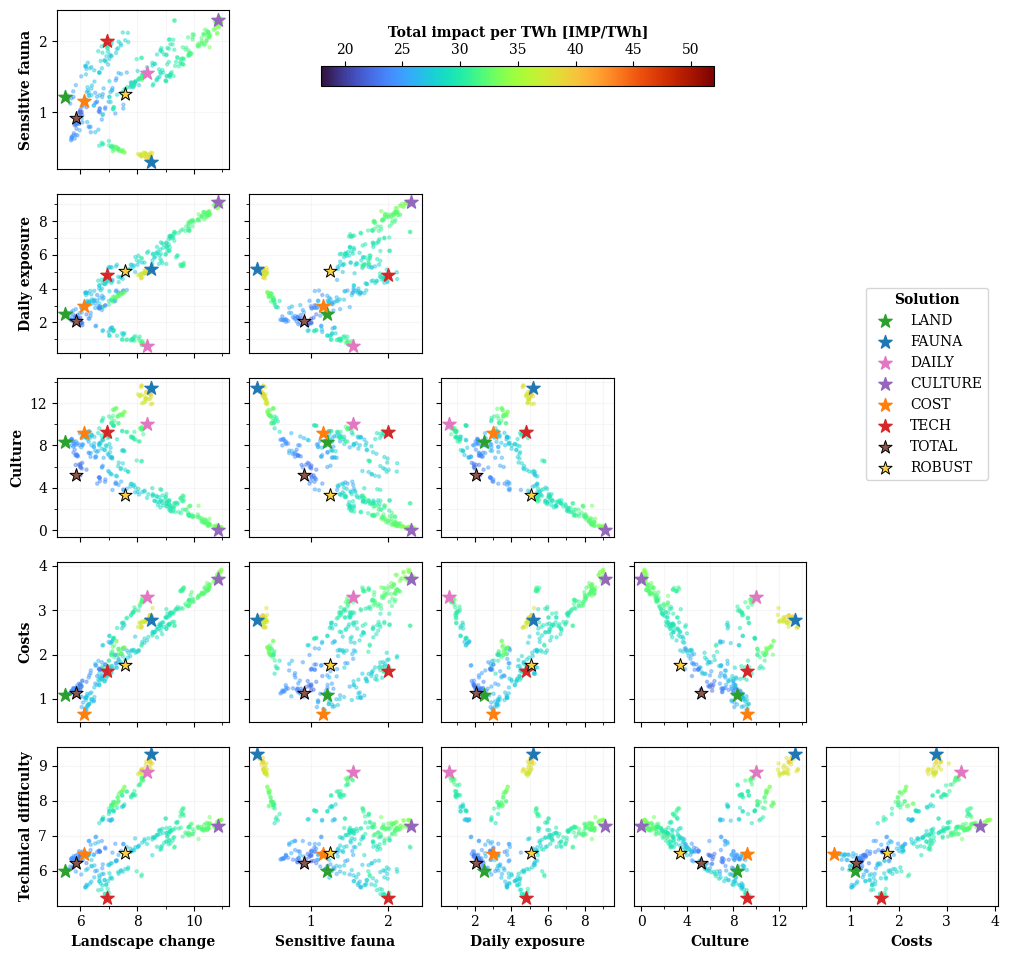

In [86]:
scatter_matrix(
    solution_df[objective_names_per_TWh].values,
    F_mcda_per_TWh_8_objectives,
    objective_names,
    solution_df["Total impact per TWh"].values,
    legend_labels=solutions_of_focus,
    cbar_label="Total impact per TWh [IMP/TWh]",
    cm_lim=(18,52),
    figsize_multiplier=1.7,
    )

# Looking at solutions of focus

In [87]:
### The first seven are in the solution_df, as they were generated by the MOO
best_total = np.argmin(solution_df["Total impact per TWh"])  # lowest techno-economic

best_Landscape = np.argmin(solution_df["Landscape change per TWh"])
best_Sensitive = np.argmin(solution_df["Sensitive fauna per TWh"])
best_Daily = np.argmin(solution_df["Daily exposure per TWh"])
best_Culture = np.argmin(solution_df["Culture per TWh"])
best_Costs = np.argmin(solution_df["Costs per TWh"])
best_Technical = np.argmin(solution_df["Technical difficulty per TWh"])

best_objectives_7 = [best_Landscape, best_Sensitive, best_Daily, best_Culture, best_Costs, best_Technical, best_total]
#best_objectives_8 = [best_Landscape, best_Sensitive, best_Daily, best_Culture, best_Costs, best_Technical, best_total, most_robust]

extremes_df = solution_df.iloc[best_objectives_7].copy()

In [88]:
### Need to make the same calculations as before for the special solution of most robust (which is not a part of the 400 solutions generated by the MOO)
robust_df = pd.DataFrame([F_most_robust], columns=objective_names)

production = X_most_robust @ my_input_data['AEP_GWh'].values
robust_df["Production"] = production

robust_df["Cells_kept"] = X_most_robust.sum()
robust_df["Total impact"] = F_most_robust.sum()

robust_df["Total area km2"] = X_most_robust @ my_input_data_extra_info["Available surface"].values

robust_df["Number turbines"] = X_most_robust @ my_input_data_extra_info["Number turbines"].values
robust_df["Number 3MW turbines"] = X_most_robust @ my_input_data_extra_info["Number 3MW turbines"].values
robust_df["Number 5MW turbines"] = X_most_robust @ my_input_data_extra_info["Number 5MW turbines"].values

# Normalize all of those metrics, as well as the objective values, by the corresponding energy production
robust_df[metrics_per_TWh] = 1000 * robust_df[metrics_absolute].div(robust_df["Production"], axis=0)

robust_df["Total land area km2"] = total_land_area
robust_df["Fraction area usage"] = solution_df["Total area km2"] / solution_df["Total land area km2"]
extremes_df = pd.concat([extremes_df, robust_df])


In [89]:
extremes_df["Minimized objective"] = solutions_of_focus
extremes_df

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,Number turbines,Number 3MW turbines,Number 5MW turbines,Landscape change per TWh,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh,Total land area km2,Fraction area usage,Minimized objective
6,546.095898,121.693892,249.252671,834.0,108.830297,600.712358,100004.771674,1140,2460.585117,1132.083750,3410.0,38.0,3372.0,5.460698,1.216881,2.492408,8.339602,1.088251,6.006837,24.604677,11.320297,34.098373,0.379982,33.718391,354037,0.003198,LAND
2,849.115982,30.443234,515.946884,1341.0,278.430758,934.508097,100012.241069,1706,3949.444955,1391.965625,4463.0,1607.0,2856.0,8.490121,0.304395,5.158837,13.408359,2.783967,9.343937,39.489616,13.917953,44.624537,16.068033,28.556504,354037,0.003932,FAUNA
10,835.321130,155.658052,60.235821,999.0,330.328238,884.126086,100052.857092,1486,3264.669327,1447.970000,4594.0,1011.0,3583.0,8.348798,1.555758,0.602040,9.984722,3.301537,8.836590,32.629446,14.472050,45.915730,10.104659,35.811071,354037,0.004090,DAILY
7,1084.210192,231.048091,912.974588,0.0,369.658335,727.510187,100021.053686,1647,3325.401392,1572.232500,5048.0,1356.0,3692.0,10.839820,2.309995,9.127824,0.000000,3.695805,7.273571,33.247014,15.719016,50.469374,13.557146,36.912229,354037,0.004441,CULTURE
1,615.462457,116.556757,297.299435,922.0,65.531327,648.589815,100073.614436,1214,2665.439791,1185.028750,3751.0,790.0,2961.0,6.150097,1.164710,2.970807,9.213218,0.654831,6.481127,26.634791,11.841570,37.482408,7.894189,29.588219,354037,0.003347,COST
4,694.767183,200.432443,479.173195,923.5,164.012595,521.154019,100005.032473,1297,2983.039434,1252.000000,3803.0,368.0,3435.0,6.947322,2.004224,4.791491,9.234535,1.640043,5.211278,29.828893,12.519370,38.028086,3.679815,34.348271,354037,0.003536,TECH
189,586.635192,92.284707,207.757769,525.0,113.049411,622.616890,100003.704030,1163,2147.343969,1160.306250,3512.0,92.0,3420.0,5.866135,0.922813,2.077501,5.249806,1.130452,6.225938,21.472644,11.602633,35.118699,0.919966,34.198733,354037,0.003277,TOTAL
0,757.863260,125.932426,505.799501,333.5,176.349134,652.263791,100038.807536,1336,2551.708113,1290.707500,4093.0,900.0,3193.0,7.575693,1.258836,5.056033,3.333706,1.762807,6.520108,25.507182,12.902068,40.914122,8.996509,31.917614,354037,0.004478,ROBUST


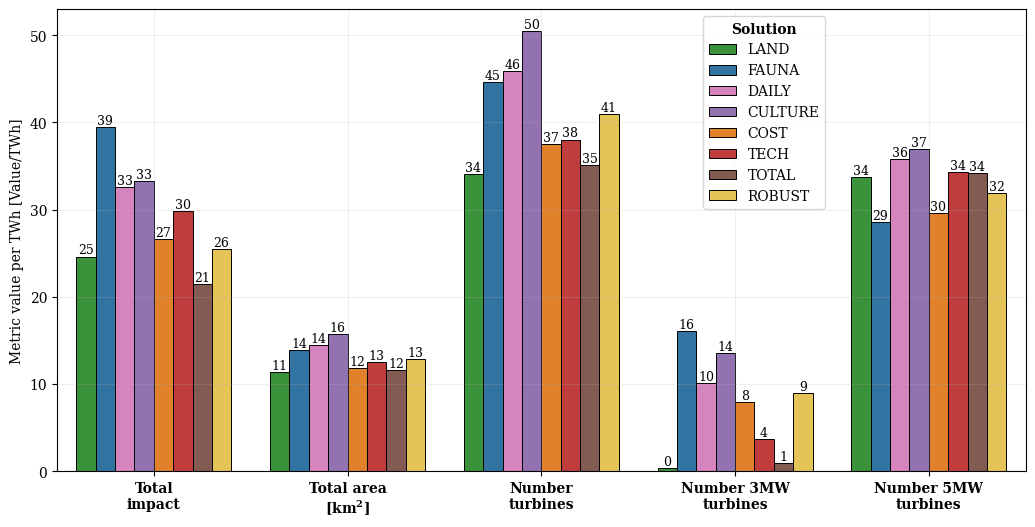

In [90]:
### Prepare a dataframe to plot the solutions of focus across other evaluation metrics (total impact, area and turbines used)
objective_vs_metric_per_TWh = extremes_df.melt(
    id_vars="Minimized objective",
    value_vars=metrics_of_interest_per_TWh,
    var_name="Metric name",
    value_name="Metric value"
)

# Plot
plt.figure(figsize=(12.5,6))
plt.tight_layout()

ax = sns.barplot(
    data=objective_vs_metric_per_TWh,
    x="Metric name",
    y="Metric value",
    hue="Minimized objective",
    palette=mcda_color_scale_8_objectives,
    linewidth=0.7, edgecolor='black'
)
ax.set_xticks(metrics_of_interest_per_TWh, labels=metrics_of_interest_plot_labels, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9)

plt.legend(
    title="Solution",
    bbox_to_anchor=(0.8, 1),
    loc="upper right",
    title_fontproperties={'weight': 'bold'},
)
plt.grid(axis="both", alpha=0.2)

plt.ylabel("Metric value per TWh [Value/TWh]")
plt.xlabel("")
#plt.title("Comparison of solutions of focus across other evaluation metrics")
plt.show()

# Option to save files of interest

In [91]:
# ### Saving the extreme and robust solutions (grid version and centroid version) in order to plot them later

# temp = my_input_data[X[best_total]].copy()
# temp.to_file(best_total_filename, driver="GPKG")
# temp["centroid"] = temp.geometry.centroid
# temp = temp.set_geometry("centroid")
# temp.drop(columns="geometry", inplace=True)
# temp.to_file(best_total_centroid_filename, driver="GPKG")

# for i, best in enumerate(best_objectives_7):
#     temp = my_input_data[X[best]].copy()
#     temp.to_file(best_objectives_7_filenames[i], driver="GPKG")
#     temp["centroid"] = temp.geometry.centroid
#     temp = temp.set_geometry("centroid")
#     temp.drop(columns="geometry", inplace=True)
#     temp.to_file(best_objectives_7_centroid_filenames[i], driver="GPKG")

# X_robustness.to_file(X_robustness_filename, driver="GPKG")
# X_robustness["centroid"] = X_robustness.geometry.centroid
# X_robustness = X_robustness.set_geometry("centroid")
# X_robustness.drop(columns="geometry", inplace=True)
# X_robustness.to_file(X_robustness_centroid_filename, driver="GPKG")

# most_robust.to_file(most_robust_filename, driver="GPKG")
# most_robust["centroid"] = most_robust.geometry.centroid
# most_robust = most_robust.set_geometry("centroid")
# most_robust.drop(columns="geometry", inplace=True)
# most_robust.to_file(most_robust_centroid_filename, driver="GPKG")

# Additional plotting code that was not retained for the thesis

In [92]:
solution_df_sorted = solution_df.sort_values("Total impact per TWh", ascending=True).copy()

In [93]:
### To study the results at the dimensions' level
F_total_env = F[:,0] + F[:,1]
F_total_soc = F[:,2] + F[:,3]
F_total_cost = F[:,4] + F[:,5]
F_combined = np.column_stack((F_total_env, F_total_soc, F_total_cost))

best_env = np.argmin(F[:,0] + F[:,1])   # Lowest nature impact
best_soc = np.argmin(F[:,2] + F[:,3])   # Lowest societal impact
best_cost = np.argmin(F[:,4] + F[:,5])  # Best techno-economic

extreme_ids = {
    "Best_Global": best_total,
    "Best_Env": best_env,
    "Best_Soc": best_soc,
    "Best_Cost": best_cost
}

extreme_ids

{'Best_Global': np.int64(189),
 'Best_Env': np.int64(158),
 'Best_Soc': np.int64(189),
 'Best_Cost': np.int64(235)}

In [94]:
# In case one wants to analyse two objectives more closely. Basically a zoom of the scatter matrix
def tradeoff_2objectives(x, y, objective_names):
    plt.figure(figsize=(6,5))
    plt.scatter(x, y, alpha=0.7)
    plt.xlabel(objective_names[0])
    plt.ylabel(objective_names[1])
    plt.title(f"{objective_names[0]} vs {objective_names[1]}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# tradeoff_2objectives(F_combined[:,0], F_combined[:,1], ["Environment", "Social"])
# tradeoff_2objectives(F_combined[:,0], F_combined[:,2], ["Environment", "Techno-economic"])
# tradeoff_2objectives(F_combined[:,1], F_combined[:,2], ["Social", "Techno-economic"])

In [95]:
### Old versions of the parallel coordinates plot, using the pymoo implementation
from pymoo.visualization.pcp import PCP

def plot_ParallelPlot(F, F_mcda):
    plot = PCP(title=("Objective values before and after optimization", {'pad': 30}),
           legend=(True, {'loc': "upper left"}),
           labels=objective_names,
           tight_layout=True)
    plot.set_axis_style(color="grey", alpha=1)

    plot.normalize_each_axis = False

    plot.add(F_mcda[0], color="tab:orange", label="Before")
    plot.add(F[0], color="tab:blue", label="After")
    plot.add(F, color="tab:blue")
    plot.add(F_mcda, color="tab:orange")
    
    plot.show()
    plt.show()


def plot_ParallelPlot_colorful(F, F_mcda):
    plot = PCP(title=("Objective values before and after optimization", {'pad': 30}),
               size=(10,20),
               legend=(True, {'loc': "upper left"}),
               labels=objective_names,
               tight_layout=True)
    plot.set_axis_style(color="grey", alpha=1)
    plot.normalize_each_axis = False

    # Scalar per solution
    score = solution_df["Total impact per TWh"]   # shape (400,) works because F is in the same order as solution_df, otherwise use next line
    
    # Color by sum of objectives
    norm = Normalize(vmin=18, vmax=52)      #score.min(), vmax=score.max())
    cmap = plt.cm.turbo
    colors_turbo = cmap(norm(score))

    for i in range(F.shape[0]):
        plot.add(F[i], color=colors_turbo[i], linewidth=0.6, alpha=0.4)

    for i in range(F_mcda.shape[0]):
        plot.add(F_mcda[i], color=mcda_color_scale_7_objectives[i], linewidth=2, alpha=1)

    plot.show()    
    plt.show()


# plot_ParallelPlot(F_per_TWh, F_mcda_per_TWh_7_objectives)
# plot_ParallelPlot_colorful(F_per_TWh, F_mcda_per_TWh_7_objectives)

In [96]:
# ### Objective value per total impact, all on one plot

# plt.figure(figsize=(12, 10))
# x = solution_df_sorted["Total impact per TWh"]
# #x = F_per_TWh.sum(axis=1)
# x_mcda = F_mcda_per_TWh_6_objectives.sum(axis=1)

# for i in range(number_objectives):
#     y = solution_df_sorted[objective_names_per_TWh[i]]
#     #y = F_per_TWh[:,i]
#     plt.scatter(x, y, s=4, alpha=0.7, color=mcda_color_scale_7_objectives[i], label=objective_names[i])

    
#     # regression line
#     m, b = np.polyfit(x, y, 1)
#     #plt.plot(x, m*x + b)
#     r, p = pearsonr(x, y)
#     print(r, p)
# for i in range(number_objectives):
#     plt.scatter(
#         x_mcda[i],
#         F_mcda_per_TWh_6_objectives[i,i],
#         s=300,
#         color=mcda_color_scale_7_objectives[i],
#         marker="*",
#         label= "MCDA " + objective_names[i]
#     )
# plt.title("Objective value per total impact")
# plt.xlabel("Total impact per TWh [-]")
# plt.ylabel("Objective value [-]")
# plt.grid(True)
# plt.legend()

# plt.show()

In [97]:
# ### Objective value per total impact, spread out over three subplots

# fig, axes = plt.subplots(3, 1, figsize=(8, 14), sharex=True)

# x = solution_df_sorted["Total impact per TWh"]

# x_mcda = F_mcda_per_TWh_7_objectives.sum(axis=1)

# handles = []
# labels = []

# pairs = [(0, 1), (2, 3), (4, 5)]

# for ax, (i, j) in zip(axes, pairs):
#     for idx in (i, j):
#         y = solution_df_sorted[objective_names_per_TWh[idx]]
#         #y = F_per_TWh[:,idx]
#         sc = ax.scatter(
#             x,
#             y,
#             s=10,
#             alpha=0.5,
#             color=mcda_color_scale_7_objectives[idx],
#             label=objective_names[idx],
#         )
#         handles.append(sc)
#         labels.append(objective_names[idx] + " MOO")
        
#         for idx_2 in range(len(x_mcda)):
#             mcda_tip = ax.scatter(
#                 x_mcda[idx_2],
#                 F_mcda_per_TWh_7_objectives[idx_2,idx],
#                 s=300,
#                 color=mcda_color_scale_7_objectives[idx_2],
#                 marker="*",
#             )
#             if idx == idx_2 or (idx == 5 and idx_2 == 6):
#                 handles.append(mcda_tip)
#                 labels.append(objective_names_7[idx_2] + " MCDA")

#     ax.set_ylim(0,14)
#     ax.grid(True)
#     ax.set_ylabel(overarching_objective_names[i//2])


# axes[-1].set_xlabel("Total impact per TWh [-]")
# fig.suptitle("Objective value per total impact")

# # single legend for the whole figure
# fig.legend(handles, labels, loc="lower right")

# plt.tight_layout(rect=(0,0,0.7,0.99))
# plt.show()

In [98]:
# ### 3D scatter plot, can be modified to look at 3 different objectives at a time
# plot = Scatter(
#     #fig_size=(16,10),
#     title="Scatter of objective results",
#     legend=True,
#     tight_layout=True,
#     labels=objective_names[:3],
#     )
# plot.reset()
# plot.normalize_each_axis = False
# #plot.bounds = [[0,0,0],[1,1,1]]
# plot.add(F[:,:3])
# plot.show()

In [99]:
# ### 3D scatter plot of higher-level objectives (the 3 dimensions of study)
# plot = Scatter(
#     fig_size=(18,16),
#     title="Scatter of objective results",
#     legend=True,
#     labels=["Environment", "Social", "Techno-economic"],
#     )
# plot.reset()
# plot.normalize_each_axis = False
# plot.bounds = [[0,0,0],[1,1,1]]
# plot.add(F_combined/len(my_input_data))
# plot.show()

In [100]:
# ### Fraction of land area used per minimized objective

# plt.figure(figsize=(10,8))
# sns.barplot(data=extremes_df, x="Minimized objective", y="Fraction area usage", hue="Minimized objective", palette=mcda_color_scale_8_objectives)
# plt.title("Fraction of land area used per minimized objective")
# plt.ylabel("Area fraction [-]")
# plt.xlabel("")
# #plt.ylim(0,1)
# plt.show()

In [101]:
# ### To compare the solutions of focus in terms of objective value (kind of a repeat from the PCP, but for the lowest values possible)

# objective_vs_objective = extremes_df.melt(
#     id_vars="Minimized objective",
#     value_vars=objective_names,
#     var_name="Objective name",
#     value_name="Objective value"
# )

# objective_vs_objective_per_TWh = extremes_df.melt(
#     id_vars="Minimized objective",
#     value_vars=objective_names_per_TWh,
#     var_name="Objective name",
#     value_name="Objective value"
# )

# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=objective_vs_objective,
#     x="Objective name",
#     y="Objective value",
#     hue="Minimized objective",
#     palette=mcda_color_scale_8_objectives
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.0f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# plt.title("Comparison of extreme solutions across variables")
# plt.show()


# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=objective_vs_objective_per_TWh,
#     x="Objective name",
#     y="Objective value",
#     hue="Minimized objective",
#     palette=mcda_color_scale_8_objectives
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.1f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# plt.title("Comparison of extreme solutions across variables")

# plt.show()

In [102]:
# ### To compare the solutions of focus in terms of metric value, like the one in the thesis, but absolute values

# objective_vs_metric = extremes_df.melt(
#     id_vars="Minimized objective",
#     value_vars=metrics_of_interest_absolute,
#     var_name="Metric name",
#     value_name="Metric value"
# )

# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=objective_vs_metric,
#     x="Metric name",
#     y="Metric value",
#     hue="Minimized objective",
#     palette=mcda_color_scale_8_objectives
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.0f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# plt.title("Comparison of extreme solutions across variables")
# plt.show()


In [103]:
# ### Fraction of cells at specific selection frequencies

# robustness_evolution = np.zeros(number_solutions)
# for i in range(number_solutions):
#     nb_selected_cells = X_robustness[X_robustness["Optimizer_selection_count"] > i].shape[0]
#     robustness_evolution[i] = nb_selected_cells

# plt.figure(figsize=(10, 8))
# plt.plot(np.arange(number_solutions)/number_solutions, robustness_evolution/X.shape[1])
# plt.hlines(most_robust.shape[0]/X.shape[1], 0, 1, colors="red", label="Minimum fraction of robust cells needed for target production")
# plt.title("Fraction of cells at specific selection frequencies")
# plt.xlabel("Selection frequency [-]")
# plt.ylabel("Cell fraction [-]")
# #plt.ylim(0,1)
# plt.grid(True)
# plt.legend()

# plt.show()

In [104]:
# ### Number of turbines versus total impact for all solutions

# plt.figure(figsize=(10, 8))
# plt.scatter(solution_df_sorted["Total impact per TWh"], solution_df_sorted["Number turbines"], label="Total turbines")
# plt.scatter(solution_df_sorted["Total impact per TWh"], solution_df_sorted["Number 3MW turbines"], label="3 MW turbines")
# plt.scatter(solution_df_sorted["Total impact per TWh"], solution_df_sorted["Number 5MW turbines"], label="5 MW turbines")

# plt.title("Number of turbines versus total impact for all solutions")
# plt.xlabel("Total impact per TWh [-]")
# plt.ylabel("Number of turbines [-]")
# plt.grid(True)
# plt.legend()

# plt.show()

In [105]:
# ### Total metrics of the solutions sorted by total impact efficiency

# plt.figure(figsize=(10, 8))

# ax = plt.gca()
# ax2 = ax.twinx()  # secondary y-axis

# x = solution_df_sorted["Total impact per TWh"]

# # left y-axis: number of turbines
# p1 = ax.scatter(x, solution_df_sorted["Number turbines"], s=25, label="Total turbines")
# p2 = ax.scatter(x, solution_df_sorted["Number 3MW turbines"], s=25, label="3 MW turbines")
# p3 = ax.scatter(x, solution_df_sorted["Number 5MW turbines"], s=25, label="5 MW turbines")

# # right y-axis: total area
# p4 = ax2.scatter(
#     x,
#     solution_df_sorted["Total area km2"],
#     label="Total area",
#     color="red",
#     marker="x"
# )
# p5 = ax2.scatter(x, solution_df_sorted["Cells_kept"], label="Number of cells", color="purple", marker="x")

# ax.set_title("Total requirements of the solutions sorted by total impact efficiency")
# ax.set_xlabel("Total impact per TWh [-]")
# ax.set_ylabel("Number of turbines [-]")
# ax2.set_ylabel(r"Total area [$\mathregular{km^2}$]")
# #ax2.set_ylim(1000, 2000)

# # Color the right y-axis (ticks, tick labels, spine, label)
# ax2.tick_params(axis="y", colors="red")
# ax2.spines["right"].set_color("red")
# ax2.yaxis.label.set_color("red")
# ax2.yaxis.label.set_color("red")

# ax.grid(True)


# # Combined legend with colored text
# handles = [p1, p2, p3, p4, p5]
# labels = [h.get_label() for h in handles]
# legend = ax.legend(handles, labels)

# for text, handle in zip(legend.get_texts(), handles):
#     if handle is p4:
#         text.set_color("red")
#     else:
#         text.set_color(handle.get_facecolor()[0])

# plt.show()


In [106]:
### Venn diagrams, showing the overlap of cells selected for various solutions

def plot_venn2(A, B, names):
    # Uses the library matplotlib-venn to plot a Venn diagram with 2 sets
    only_A = np.sum((A == 1) & (B == 0))
    only_B = np.sum((A == 0) & (B == 1))
    both   = np.sum((A == 1) & (B == 1))

    venn2(subsets=(only_A, only_B, both), set_labels=names)
    plt.show()


def plot_venn3(A, B, C, names):
    # Uses the library matplotlib-venn to plot a Venn diagram with 3 sets
    venn3(
        subsets=(
            np.sum((A==1)&(B==0)&(C==0)),  # A only
            np.sum((A==0)&(B==1)&(C==0)),  # B only
            np.sum((A==1)&(B==1)&(C==0)),  # A & B
            np.sum((A==0)&(B==0)&(C==1)),  # C only
            np.sum((A==1)&(B==0)&(C==1)),  # A & C
            np.sum((A==0)&(B==1)&(C==1)),  # B & C
            np.sum((A==1)&(B==1)&(C==1)),  # A & B & C
        ),
        set_labels=names
    )

    plt.show()

In [107]:
# plot_venn2(X[best_total], X_most_robust, ("Lowest total impact", "Most robust cells"))
# plot_venn2(X[best_total], X_mcda_7_objectives[-1], ("Lowest total impact MOO", "Lowest total impact MCDA"))

# plot_venn2(X[best_Landscape], X_mcda_7_objectives[0], ("Best landscape change MOO", "Best landscape change MCDA"))
# plot_venn2(X[best_Sensitive], X_mcda_7_objectives[1], ("Best sensitive fauna MOO", "Best sensitive fauna MCDA"))
# plot_venn2(X[best_Daily], X_mcda_7_objectives[2], ("Best daily exposure MOO", "Best daily exposure MCDA"))
# plot_venn2(X[best_Culture], X_mcda_7_objectives[3], ("Best culture MOO", "Best culture MCDA"))
# plot_venn2(X[best_Costs], X_mcda_7_objectives[4], ("Best costs MOO", "Best costs MCDA"))
# plot_venn2(X[best_Technical], X_mcda_7_objectives[5], ("Best technical MOO", "Best technical MCDA"))

# plot_venn3(X[best_env], X[best_soc], X[best_cost], ("Best environmental", "Best social", "Best cost"))

# plot_venn3(X[best_env], X[best_Landscape], X[best_Sensitive], ("Best environmental", "Best landscape change", "Best sensitive fauna"))
# plot_venn3(X[best_soc], X[best_Daily], X[best_Culture], ("Best social", "Best daily exposure", "Best culture"))
# plot_venn3(X[best_cost], X[best_Costs], X[best_Technical], ("Best techno-economic", "Best costs", "Best technical"))

# plot_venn3(X[best_Landscape], X[best_Daily], X[best_Technical], ("Best landscape change", "Best daily exposure", "Best technical"))
# plot_venn3(X[best_Landscape], X[best_Culture], X[best_Technical], ("Best landscape change", "Best culture", "Best technical"))
# plot_venn3(X[best_Landscape], X[best_Daily], X[best_Costs], ("Best landscape change", "Best daily exposure", "Best costs"))
# plot_venn3(X[best_Landscape], X[best_Costs], X[best_Technical], ("Best landscape change", "Best costs", "Best technical"))
# plot_venn3(X[best_Sensitive], X[best_Daily], X[best_Technical], ("Best sensitive fauna", "Best daily exposure", "Best technical"))
# plot_venn3(X[best_Sensitive], X[best_Culture], X[best_Costs], ("Best sensitive fauna", "Best culture", "Best costs"))